In [1]:
%matplotlib widget

In [3]:
# ============================================================
# IMPORTS
# ============================================================
from pathlib import Path

import sys
import warnings

warnings.filterwarnings("ignore")


# ============================================================
# PROJECT ROOT
# ============================================================
PROJECT_ROOT = Path.cwd().parent.parent

sys.path.append(
    str(PROJECT_ROOT)
)

# ============================================================
# DATA
# ============================================================
from src.data.wwi_wwii_predictive_analysis_scalability_of_conflict import (
    load_data
)

# ============================================================
# FEATURES
# ============================================================
from src.features.wwi_wwii_build_temporal_generation_wars_deaths import (
    expand_conflicts_monthly
)

from src.features.wwi_wwii_build_features_wars_deaths import (
    build_features
)

# ============================================================
# MODELS
# ============================================================
from src.models.train_model_wars_deaths import (
    temporal_split,
    train_model,
    evaluate_model,
    feature_importance,
    save_model
)


Loading WWI + WWII Dataset...

Dataset Shape:
(20000, 13)

Wars:
war_name
WWI     10000
WWII    10000
Name: count, dtype: int64

Generating Monthly Timeline...
Processing 0/20,000
Processing 1,000/20,000
Processing 2,000/20,000
Processing 3,000/20,000
Processing 4,000/20,000
Processing 5,000/20,000
Processing 6,000/20,000
Processing 7,000/20,000
Processing 8,000/20,000
Processing 9,000/20,000
Processing 10,000/20,000
Processing 11,000/20,000
Processing 12,000/20,000
Processing 13,000/20,000
Processing 14,000/20,000
Processing 15,000/20,000
Processing 16,000/20,000
Processing 17,000/20,000
Processing 18,000/20,000
Processing 19,000/20,000

Expanded Shape:
(1199652, 14)

Building Features...

Feature Engineering Completed.

Target Distribution:
next_month_escalation
0    0.587571
1    0.412429
Name: proportion, dtype: float64

Temporal Dataset Saved.

Applying Temporal Split...

Training LightGBM...
[LightGBM] [Info] Number of positive: 390641, number of negative: 559791
[LightGBM] [Inf

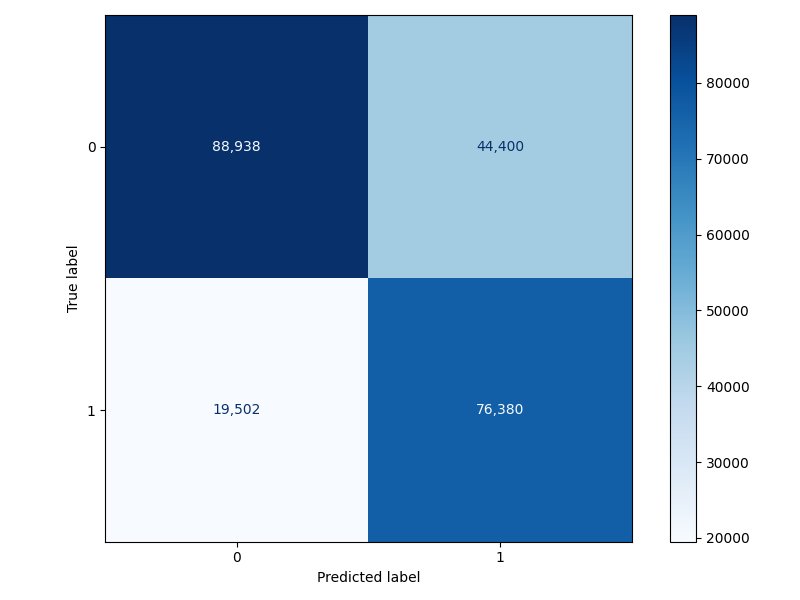


Feature Importance:

                 feature  importance
0         current_deaths        3095
15      casualties_mil_k        1516
7         rolling_mean_3        1326
16      casualties_civ_k        1273
14             war_phase        1147
10                ewma_6         922
8         rolling_mean_6         878
11              momentum         856
3                  lag_3         806
1                  lag_1         686
12            volatility         504
6            growth_rate         463
5                delta_2         368
9          rolling_std_6         302
18        casualty_ratio         290
4                delta_1         288
2                  lag_2         271
17  military_personnel_k         196
13          acceleration         167
20       country_encoded          47
19              war_type          45
22         front_encoded          42
21      alliance_encoded          12

Model Saved:
C:\Users\Ersbr\Pictures\Que_Saco\international-conflict-risk-ml\models\advan

In [4]:
# ============================================================
# LOAD DATA
# ============================================================
raw_df = load_data()


# ============================================================
# TEMPORAL GENERATION
# ============================================================
temporal_df = expand_conflicts_monthly(
    raw_df
)

# ============================================================
# FEATURE ENGINEERING
# ============================================================

feature_df, features = build_features(
    temporal_df
)

# ============================================================
# GENERATED DATA DIRECTORY
# ============================================================
GENERATED_DIR = (
    PROJECT_ROOT /
    "data" /
    "generated"
)

GENERATED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# SAVE TEMPORAL DATASET
# ============================================================
TEMPORAL_DATASET = (
    GENERATED_DIR /
    "advanced_temporal_conflict_dataset_wwi+wwii.parquet"
)

feature_df.to_parquet(
    TEMPORAL_DATASET,
    index=False
)

print("\nTemporal Dataset Saved.")

# ============================================================
# TEMPORAL SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test

) = temporal_split(
    feature_df,
    features
)

# ============================================================
# TRAIN MODEL
# ============================================================
model = train_model(
    X_train,
    y_train
)

# ============================================================
# EVALUATE MODEL
# ============================================================
evaluate_model(
    model,
    X_test,
    y_test
)

# ============================================================
# FEATURE IMPORTANCE
# ============================================================
feature_importance(
    model,
    features
)

# ============================================================
# SAVE MODEL
# ============================================================
save_model(model)

# ============================================================
# FINISHED
# ============================================================
print("\nPipeline Completed Successfully.")